# 03  -  Feature Engineering

**Inputs:** `outputs/*_processed.csv`  
**Outputs:** `outputs/*_features.csv`

In [1]:
exec(open('00_config.py').read())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cc = pd.read_csv(CC_PROCESSED_CSV)
mm = pd.read_csv(MM_PROCESSED_CSV)
hi = pd.read_csv(HI_PROCESSED_CSV)
print(f'Loaded: CC={cc.shape}  MM={mm.shape}  HI={hi.shape}')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH
Loaded: CC=(1852394, 19)  MM=(550357, 16)  HI=(2655, 31)


## 1. Universal Behavioral Features

In [2]:
def add_universal_features(df, amount_col, domain_name):
    """
    Amount anomaly + velocity proxies applied to all three domains.
    True per-account velocity requires persistent IDs which MoMTSim and HI
    don't have, so dataset-level proxies are used instead.
    """
    df = df.copy()

    if amount_col and amount_col in df.columns:
        median = df[amount_col].median()
        mad    = (df[amount_col] - median).abs().median() + 1e-8
        df['amount_zscore']        = (df[amount_col] - median) / mad
        df['amount_deviation_pct'] = ((df[amount_col] - median) / (median + 1e-8)).abs()
        df['is_large_transaction'] = (df['amount_zscore'] > 3).astype(int)
        df['is_micro_transaction'] = (df[amount_col] < df[amount_col].quantile(0.01)).astype(int)

    time_col = next((c for c in df.columns if any(k in c.lower() for k in ['hour','time','step','day_of_sim'])), None)
    if time_col:
        df['time_since_prev']  = df[time_col].diff().abs().fillna(0)
        df['rapid_succession'] = (df['time_since_prev'] < 1).astype(int)
        window_counts         = df[time_col].value_counts()
        thresh95              = window_counts.quantile(0.95)
        df['tx_burst_flag']   = df[time_col].map(window_counts).ge(thresh95).astype(int)
    else:
        df['time_since_prev'] = df['rapid_succession'] = df['tx_burst_flag'] = 0

    hour_col = next((c for c in df.columns if 'hour' in c.lower() and 'sin' not in c and 'cos' not in c), None)
    if hour_col:
        peak = set(range(7,10)) | set(range(12,15)) | set(range(17,21))
        df['unusual_timing'] = (~df[hour_col].astype(int).isin(peak)).astype(int)

    print(f'  [{domain_name}] universal features added')
    return df

cc_amount = next((c for c in ['amt','Amount','amount'] if c in cc.columns), None)
mm_amount = next((c for c in mm.columns if c.lower() == 'amount'), None)
hi_amount = next((c for c in hi.columns if 'total' in c.lower() and 'tariff' not in c.lower()), None)

cc = add_universal_features(cc, cc_amount, 'Credit Card')
mm = add_universal_features(mm, mm_amount, 'Mobile Money')
hi = add_universal_features(hi, hi_amount, 'Health Insurance')

  [Credit Card] universal features added
  [Mobile Money] universal features added
  [Health Insurance] universal features added


## 2. Credit Card Domain Features

In [3]:
def add_credit_card_features(df):
    df = df.copy()
    cols = {c.lower(): c for c in df.columns}

    def find(name):
        return next((cols[n] for n in [name, name.lower()] if n in cols), None)

    amt_col = find('amt') or find('amount')
    if amt_col:
        df['is_high_value']   = (df[amt_col] > df[amt_col].quantile(0.95)).astype(int)
        df['amount_is_round'] = (df[amt_col] % 10 < 0.01).astype(int)
        df['amt_ghs']         = df[amt_col] * USD_TO_GHS
        df['is_high_value_ghs'] = (df['amt_ghs'] > 10000).astype(int)

    cat_col = find('category')
    if cat_col:
        df['high_risk_category'] = (df[cat_col] > df[cat_col].quantile(0.75)).astype(int)

    merch_col = find('merchant')
    if merch_col:
        df['high_risk_merchant'] = (df[merch_col] > df[merch_col].quantile(0.75)).astype(int)

    lat, lng, mlat, mlng = find('lat'), find('long'), find('merch_lat'), find('merch_long')
    if all([lat, lng, mlat, mlng]):
        df['geo_distance']    = np.sqrt((df[lat]-df[mlat])**2 + (df[lng]-df[mlng])**2)
        df['long_distance_tx'] = (df['geo_distance'] > df['geo_distance'].quantile(0.90)).astype(int)

    dob_col = find('dob')
    if dob_col and df[dob_col].dtype == object:
        try:
            df['cardholder_age'] = (pd.Timestamp.now() - pd.to_datetime(df[dob_col])).dt.days // 365
            df['is_senior'] = (df['cardholder_age'] >= 65).astype(int)
            df['is_young']  = (df['cardholder_age'] <  25).astype(int)
        except Exception:
            pass

    pop_col = find('city_pop')
    if pop_col:
        df['is_rural_tx'] = (df[pop_col] < df[pop_col].median()).astype(int)

    return df

cc = add_credit_card_features(cc)
print(f'CC: {cc.shape[1]} features')

CC: 36 features


## 3. Mobile Money Domain Features

In [4]:
def add_mobile_money_features(df):
    df = df.copy()
    amt_col = next((c for c in df.columns if c.lower() == 'amount'), None)

    # Balance inconsistency  -  primary fraud signal in MoMTSim
    for prefix in ['Orig', 'Dest']:
        old = next((c for c in df.columns if f'oldbalance{prefix}'.lower() in c.lower()), None)
        new = next((c for c in df.columns if f'newbalance{prefix}'.lower() in c.lower()), None)
        if old and new and amt_col:
            df[f'balance_error_{prefix.lower()}']  = (df[old] - df[new] - df[amt_col]).abs()
            df[f'balance_zeroed_{prefix.lower()}'] = (df[new] == 0).astype(int)

    if amt_col:
        df['amount_ghs']        = df[amt_col] * USD_TO_GHS
        df['is_high_value_ghs'] = (df['amount_ghs'] > 10000).astype(int)
        # Proxy for agent cash-outs: high-value round-amount transfers
        df['is_agent_proxy'] = (
            (df['amount_ghs'] > 500) & (df[amt_col] % 10 < 0.01)
        ).astype(int)

    return df

mm = add_mobile_money_features(mm)
print(f'MM: {mm.shape[1]} features')

MM: 27 features


## 4. Health Insurance Domain Features

In [5]:
def add_health_insurance_features(df):
    df = df.copy()

    overbill_cols = [c for c in df.columns if 'overbill' in c.lower() or 'dev_' in c]
    if overbill_cols:
        df['multi_field_overbill'] = (df[overbill_cols] > 0).sum(axis=1)

    svc   = next((c for c in df.columns if 'service' in c.lower() and 'tariff' not in c.lower()), None)
    total = next((c for c in df.columns if 'total'   in c.lower() and 'tariff' not in c.lower()), None)
    if svc and total:
        df['service_to_total_ratio'] = (df[svc] / (df[total].replace(0, np.nan) + 1e-8)).clip(0, 5)
        df['is_service_dominant']    = (df['service_to_total_ratio'] > 0.8).astype(int)

    dev_cols = [c for c in df.columns if c.startswith('dev_')]
    if dev_cols:
        df['max_deviation'] = df[dev_cols].max(axis=1)
        df['is_overbilled'] = (df['max_deviation'] > 0).astype(int)

    return df

hi = add_health_insurance_features(hi)
print(f'HI: {hi.shape[1]} features')

HI: 43 features


## 5. AHIN Network Features (Health Insurance)

In [6]:
def build_network_features(df):
    df = df.copy()
    drg_col = next((c for c in df.columns if any(k in c.upper() for k in ['DRG','GDRG'])), None)
    if drg_col is None:
        return df

    df['drg_claim_volume'] = df[drg_col].map(df[drg_col].value_counts()).fillna(0)

    if TARGET_COL in df.columns:
        global_rate = df[TARGET_COL].mean()
        stats = df.groupby(drg_col)[TARGET_COL].agg(['sum','count'])
        k = 10  # smoothing strength toward global mean
        stats['smooth'] = (stats['sum'] + global_rate * k) / (stats['count'] + k)
        df['drg_fraud_rate'] = df[drg_col].map(stats['smooth']).fillna(global_rate)

    bill_col = next((c for c in df.columns if 'total' in c.lower() and 'tariff' not in c.lower()), None)
    if bill_col:
        df['drg_billing_variability'] = df[drg_col].map(
            df.groupby(drg_col)[bill_col].std().fillna(0)
        ).fillna(0)

    return df

hi = build_network_features(hi)
print(f'HI with AHIN: {hi.shape[1]} features')

HI with AHIN: 46 features


## 6. Feature Selection (Variance -> Correlation -> RF Importance)

In [7]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

def select_features(df, domain_name, n_top=25, sample_size=50000):
    print(f'\n--- {domain_name} ---')
    X = df.drop(columns=[TARGET_COL], errors='ignore').select_dtypes(include=np.number).fillna(0)
    y = df[TARGET_COL] if TARGET_COL in df.columns else None
    if y is None:
        return df, X.columns.tolist()

    # Stage 1a: variance threshold
    sel = VarianceThreshold(threshold=0.001)
    X = pd.DataFrame(sel.fit_transform(X), columns=X.columns[sel.get_support()])
    print(f'  After variance: {X.shape[1]}')

    # Stage 1b: correlation filter
    upper = X.corr().abs().where(np.triu(np.ones(X.corr().shape), k=1).astype(bool))
    X = X.drop(columns=[c for c in upper.columns if any(upper[c] > 0.95)])
    print(f'  After corr filter: {X.shape[1]}')

    # Stage 2: RF importance on a sample (handles CC at 1.85M rows)
    if len(X) > sample_size:
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X), sample_size, replace=False)
        X_s, y_s = X.iloc[idx], y.iloc[idx]
        print(f'  RF on sample: {sample_size:,}')
    else:
        X_s, y_s = X, y

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_s, y_s)
    top = pd.Series(rf.feature_importances_, index=X.columns).nlargest(n_top).index.tolist()
    print(f'  Selected: {len(top)} features')
    return df[top + [TARGET_COL]], top

cc_feat, cc_feat_names = select_features(cc, 'Credit Card',      n_top=25)
mm_feat, mm_feat_names = select_features(mm, 'Mobile Money',     n_top=25)
hi_feat, hi_feat_names = select_features(hi, 'Health Insurance', n_top=25)


--- Credit Card ---
  After variance: 18
  After corr filter: 14
  RF on sample: 50,000
  Selected: 14 features

--- Mobile Money ---
  After variance: 15
  After corr filter: 9
  RF on sample: 50,000
  Selected: 9 features

--- Health Insurance ---
  After variance: 33
  After corr filter: 30
  Selected: 25 features


## 7. Save

In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
cc_feat.to_csv(CC_FEATURES_CSV, index=False)
mm_feat.to_csv(MM_FEATURES_CSV, index=False)
hi_feat.to_csv(HI_FEATURES_CSV, index=False)

print(f'CC  -> {CC_FEATURES_CSV}  {cc_feat.shape}')
print(f'MM  -> {MM_FEATURES_CSV}  {mm_feat.shape}')
print(f'HI  -> {HI_FEATURES_CSV}  {hi_feat.shape}')

CC  -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/credit_card_features.csv  (1852394, 15)
MM  -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/mobile_money_features.csv  (550357, 10)
HI  -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/health_insurance_features.csv  (2655, 26)


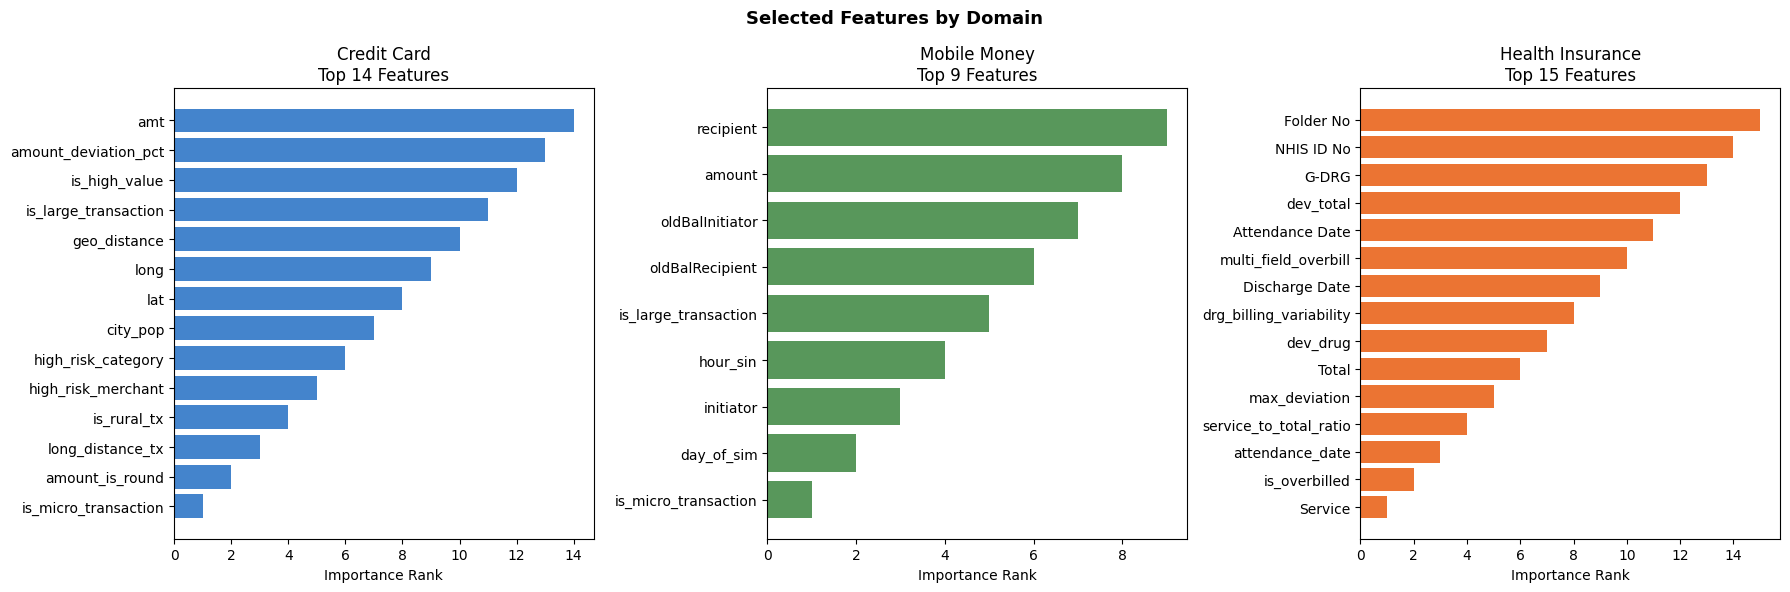

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name, feats, color in zip(axes,
    ['Credit Card','Mobile Money','Health Insurance'],
    [cc_feat_names, mm_feat_names, hi_feat_names],
    ['#1565C0','#2E7D32','#E65100']):
    show = feats[:15][::-1]
    ax.barh(show, range(1, len(show)+1), color=color, alpha=0.8)
    ax.set_title(f'{name}\nTop {len(show)} Features')
    ax.set_xlabel('Importance Rank')

plt.suptitle('Selected Features by Domain', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, '03_feature_sets.png'), dpi=150, bbox_inches='tight')
plt.show()